In [32]:
# ============================================================
#              INDIAN STARTUP FUNDING ANALYSIS
#                    Python + EDA Project
# ============================================================

# -----------------------------
# 1. IMPORT REQUIRED LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Beautiful styling for charts
plt.style.use("ggplot")
sns.set(rc={'figure.figsize':(12, 6)}, font_scale=1.1)


In [35]:
# -----------------------------
# 2. LOAD THE DATASET
# -----------------------------
df = pd.read_csv("/content/startup_funding.csv", encoding='latin1')
print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,ï»¿Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJUâS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [36]:
# -----------------------------
# 3. BASIC DATA UNDERSTANDING
# -----------------------------
print(df.info())
print(df.describe(include="all"))
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ï»¿Sr No           3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB
None
           ï»¿Sr No Date dd/mm/yyyy Startup Name  Industry Vertical  \
count   3044.000000            3044         3044               2873   
unique          NaN            1035         2459                821   
top             NaN      30/11/2016       Swiggy  Consumer 

In [37]:
# ============================================================
#               4. DATA CLEANING & TRANSFORMATION
# ============================================================

# Strip all column names to remove spaces
df.columns = df.columns.str.strip()

# Check the column names
print("Columns in dataset:", df.columns)

# ---- 4.1 Clean Startup Name ----
if 'Startup Name' in df.columns:
    df['Startup Name'] = df['Startup Name'].astype(str).str.strip().str.title()
else:
    print("Warning: 'Startup Name' column not found!")

# ---- 4.2 Clean Industry Vertical ----
if 'Industry Vertical' in df.columns:
    df['Industry Vertical'] = df['Industry Vertical'].fillna("Not Specified")
else:
    print("Warning: 'Industry Vertical' column not found!")

# ---- 4.3 Identify funding column ----
# Sometimes it's 'Amount', 'Amount in USD', 'Raised Amount', etc.
funding_columns = ['Amount', 'Amount in USD', 'Raised Amount', 'Funding Amount']
amount_col = None
for col in funding_columns:
    if col in df.columns:
        amount_col = col
        break

if amount_col is None:
    raise KeyError("No funding column found in dataset. Check column names:", df.columns)
else:
    df.rename(columns={amount_col: 'Amount'}, inplace=True)

# ---- 4.4 Convert Amount to Numeric ----
def clean_amount(x):
    try:
        if pd.isnull(x):
            return np.nan
        x = str(x).replace(",", "").replace("₹", "").replace("$", "").lower().strip()
        if "crore" in x:
            return float(x.split()[0]) * 10000000
        elif "lakh" in x:
            return float(x.split()[0]) * 100000
        elif "m" in x:
            return float(x.replace("m","")) * 1000000
        else:
            return float(x)
    except:
        return np.nan

df['Amount'] = df['Amount'].apply(clean_amount)

# ---- 4.5 Convert Date to Year ----
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year
else:
    print("Warning: 'Date' column not found!")

# ---- 4.6 Drop rows with no amount ----
df = df.dropna(subset=['Amount']).reset_index(drop=True)

print("Data cleaning complete!")
print("Dataset shape after cleaning:", df.shape)


Columns in dataset: Index(['ï»¿Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='object')
Data cleaning complete!
Dataset shape after cleaning: (2065, 10)


In [38]:
# -----------------------------
# CLEAN COLUMN NAMES
# -----------------------------
df.columns = df.columns.str.replace('ï»¿','', regex=False)  # Remove BOM
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
df.columns = df.columns.str.replace(' ', '_')  # Replace spaces with underscores
df.columns = df.columns.str.replace('/', '_')  # Replace slashes

# Map dataset columns to standard names
df.rename(columns={
    'Date_dd_mm_yyyy': 'Date',
    'Startup_Name': 'Startup Name',
    'Industry_Vertical': 'Industry Vertical',
    'City_Location': 'City',
    'Investors_Name': 'Investors Name'
}, inplace=True)

print("Cleaned Columns:", df.columns)


Cleaned Columns: Index(['Sr_No', 'Date', 'Startup Name', 'Industry Vertical', 'SubVertical',
       'City__Location', 'Investors Name', 'InvestmentnType', 'Amount',
       'Remarks'],
      dtype='object')


In [40]:
# ============================================================
# 4. DATA CLEANING & TRANSFORMATION
# ============================================================

# ---- Clean Startup Name ----
df['Startup Name'] = df['Startup Name'].astype(str).str.strip().str.title()

# ---- Clean Industry Vertical ----
df['Industry Vertical'] = df['Industry Vertical'].fillna("Not Specified")

# ---- Convert Amount to Numeric ----
def clean_amount(x):
    try:
        if pd.isnull(x):
            return np.nan
        x = str(x).replace(",", "").replace("₹", "").replace("$", "").lower().strip()
        if "crore" in x:
            return float(x.split()[0]) * 10000000
        elif "lakh" in x:
            return float(x.split()[0]) * 100000
        elif "m" in x:
            return float(x.replace("m","")) * 1000000
        else:
            return float(x)
    except:
        return np.nan

df['Amount'] = df['Amount'].apply(clean_amount)

# ---- Convert Date to Year ----
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

# ---- Drop rows with no amount ----
df = df.dropna(subset=['Amount']).reset_index(drop=True)
print("Data Cleaning Complete! Shape:", df.shape)


Data Cleaning Complete! Shape: (2065, 11)


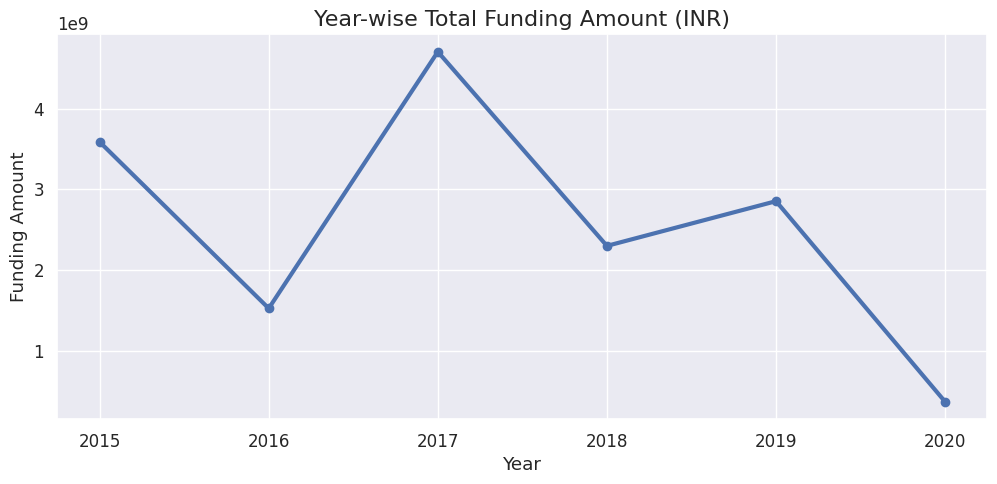

In [41]:
# ============================================================
# 5.1 FUNDING TREND OVER THE YEARS
# ============================================================
yearly_funding = df.groupby("Year")["Amount"].sum()

plt.figure(figsize=(12, 5))
plt.plot(yearly_funding.index, yearly_funding.values, marker='o', linewidth=3)
plt.title("Year-wise Total Funding Amount (INR)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Funding Amount")
plt.grid(True)
plt.show()


/tmp/ipython-input-2481758379.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_funding.values, y=sector_funding.index, palette="viridis")


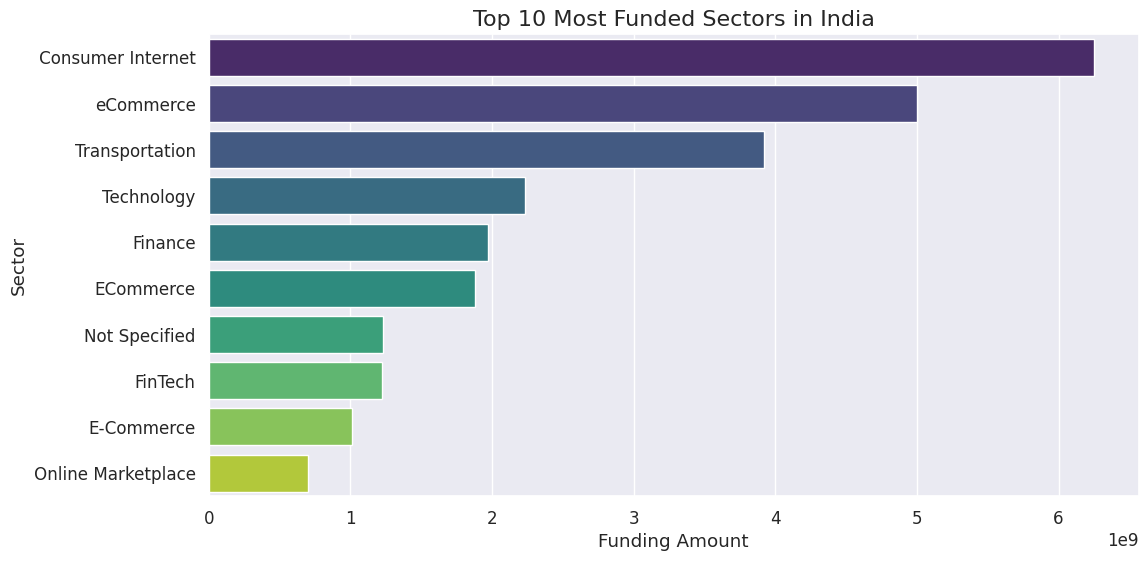

In [42]:
# ============================================================
# 5.2 TOP 10 MOST FUNDED SECTORS
# ============================================================
sector_funding = df.groupby("Industry Vertical")["Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=sector_funding.values, y=sector_funding.index, palette="viridis")
plt.title("Top 10 Most Funded Sectors in India", fontsize=16)
plt.xlabel("Funding Amount")
plt.ylabel("Sector")
plt.show()


In [43]:
# -----------------------------
# CLEAN COLUMN NAMES
# -----------------------------
# Remove BOM and non-printable characters
df.columns = df.columns.str.encode('ascii', 'ignore').str.decode('ascii')

# Strip leading/trailing spaces and replace all spaces with single underscore
df.columns = df.columns.str.strip().str.replace(r'\s+', '_', regex=True)

# Replace slashes
df.columns = df.columns.str.replace('/', '_')

# Rename important columns for consistency
df.rename(columns={
    'Date_dd_mm_yyyy': 'Date',
    'Startup_Name': 'Startup Name',
    'Industry_Vertical': 'Industry Vertical',
    'City_Location': 'City',       # <- important
    'Investors_Name': 'Investors Name'
}, inplace=True)

print("Columns after cleaning:", df.columns)


Columns after cleaning: Index(['Sr_No', 'Date', 'Startup Name', 'Industry Vertical', 'SubVertical',
       'City__Location', 'Investors Name', 'InvestmentnType', 'Amount',
       'Remarks', 'Year'],
      dtype='object')


In [50]:
# Show all columns with hidden characters
for i, col in enumerate(df.columns):
    print(i, repr(col))


0 'Sr_No'
1 'Date'
2 'Startup Name'
3 'Industry Vertical'
4 'SubVertical'
5 'City__Location'
6 'Investors Name'
7 'InvestmentnType'
8 'Amount'
9 'Remarks'
10 'Year'


In [51]:
# Remove BOM & non-printable characters
df.columns = df.columns.str.encode('ascii', 'ignore').str.decode('ascii')

# Strip spaces and replace multiple spaces with underscore
df.columns = df.columns.str.strip().str.replace(r'\s+', '_', regex=True)

# Replace slashes
df.columns = df.columns.str.replace('/', '_')

# Rename important columns
df.rename(columns={
    'Date_dd_mm_yyyy': 'Date',
    'Startup_Name': 'Startup Name',
    'Industry_Vertical': 'Industry Vertical',
    'City_Location': 'City',       # Important fix
    'Investors_Name': 'Investors Name',
    'Amount_in_USD_or_INR': 'Amount'  # If Amount has strange name
}, inplace=True)

# Confirm final column names
print(df.columns)


Index(['Sr_No', 'Date', 'Startup Name', 'Industry Vertical', 'SubVertical',
       'City__Location', 'Investors Name', 'InvestmentnType', 'Amount',
       'Remarks', 'Year'],
      dtype='object')


In [55]:
for i, col in enumerate(df.columns):
    print(i, repr(col))


0 'Sr_No'
1 'Date'
2 'Startup Name'
3 'Industry Vertical'
4 'SubVertical'
5 'City__Location'
6 'Investors Name'
7 'InvestmentnType'
8 'Amount'
9 'Remarks'
10 'Year'


In [56]:
# Rename City column (replace the 5th column with proper name)
df.rename(columns={df.columns[5]: 'City'}, inplace=True)

# Confirm
print(df.columns)
print(df['City'].head())


Index(['Sr_No', 'Date', 'Startup Name', 'Industry Vertical', 'SubVertical',
       'City', 'Investors Name', 'InvestmentnType', 'Amount', 'Remarks',
       'Year'],
      dtype='object')
0    Bengaluru
1      Gurgaon
2    Bengaluru
3    New Delhi
4       Mumbai
Name: City, dtype: object


In [57]:
# Example conversion
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df = df.dropna(subset=['Amount'])


/tmp/ipython-input-1791226748.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_funding.values, y=city_funding.index, palette="magma")


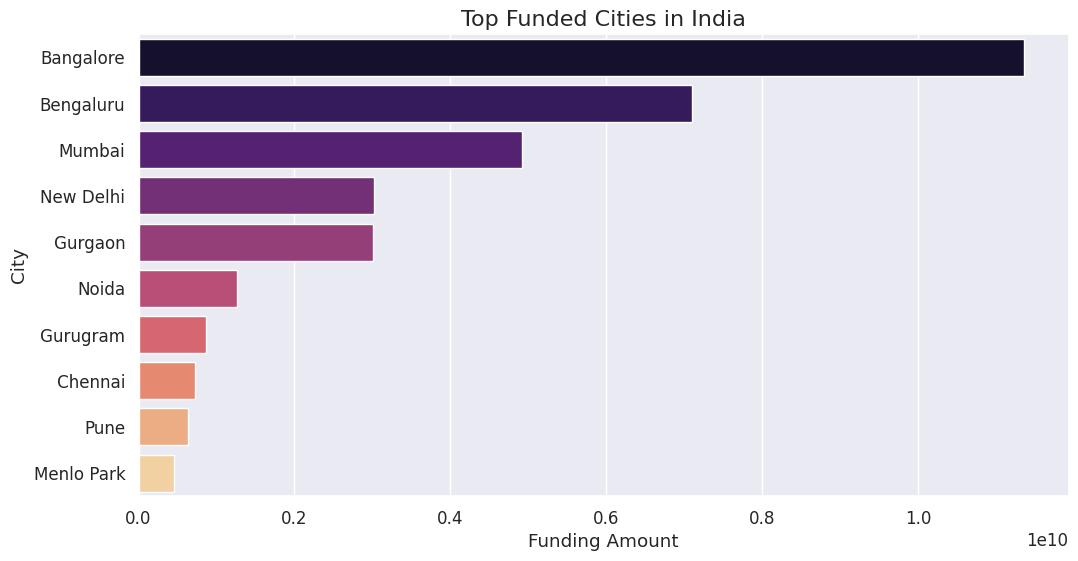

In [58]:
city_funding = df.groupby("City")["Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=city_funding.values, y=city_funding.index, palette="magma")
plt.title("Top Funded Cities in India", fontsize=16)
plt.xlabel("Funding Amount")
plt.ylabel("City")
plt.show()


/tmp/ipython-input-366370062.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_investors.values, y=top_investors.index, palette="cool")


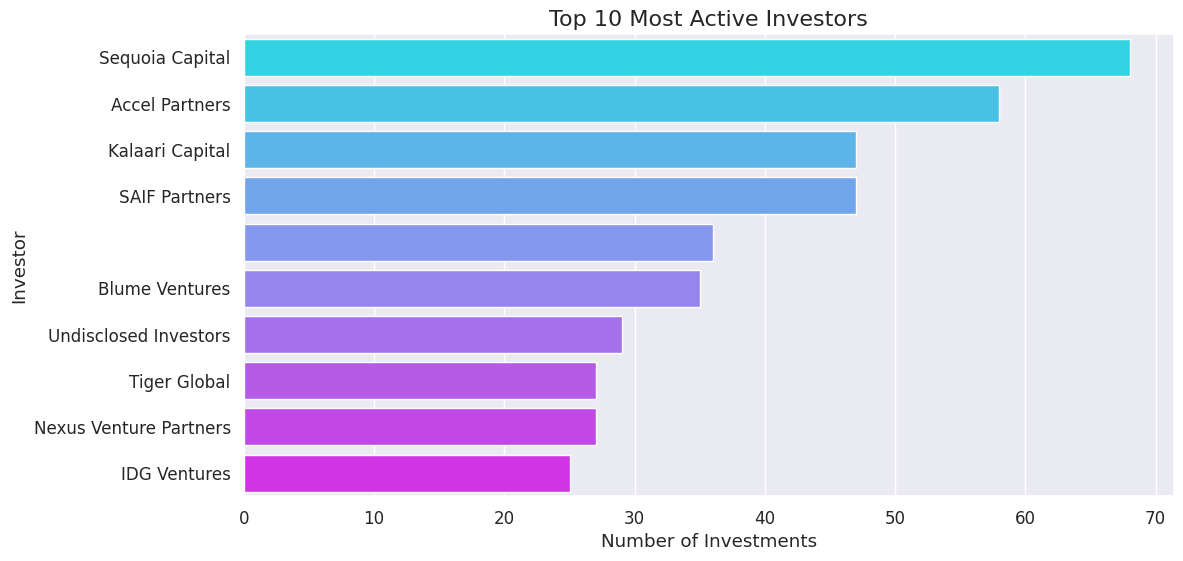

In [59]:
# ============================================================
# 5.4 TOP 10 MOST ACTIVE INVESTORS
# ============================================================
investors = df['Investors Name'].str.split(",", expand=True).stack().str.strip()
top_investors = investors.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_investors.values, y=top_investors.index, palette="cool")
plt.title("Top 10 Most Active Investors", fontsize=16)
plt.xlabel("Number of Investments")
plt.ylabel("Investor")
plt.show()


/tmp/ipython-input-65351442.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_sector_funding.values, y=avg_sector_funding.index, palette="cubehelix")


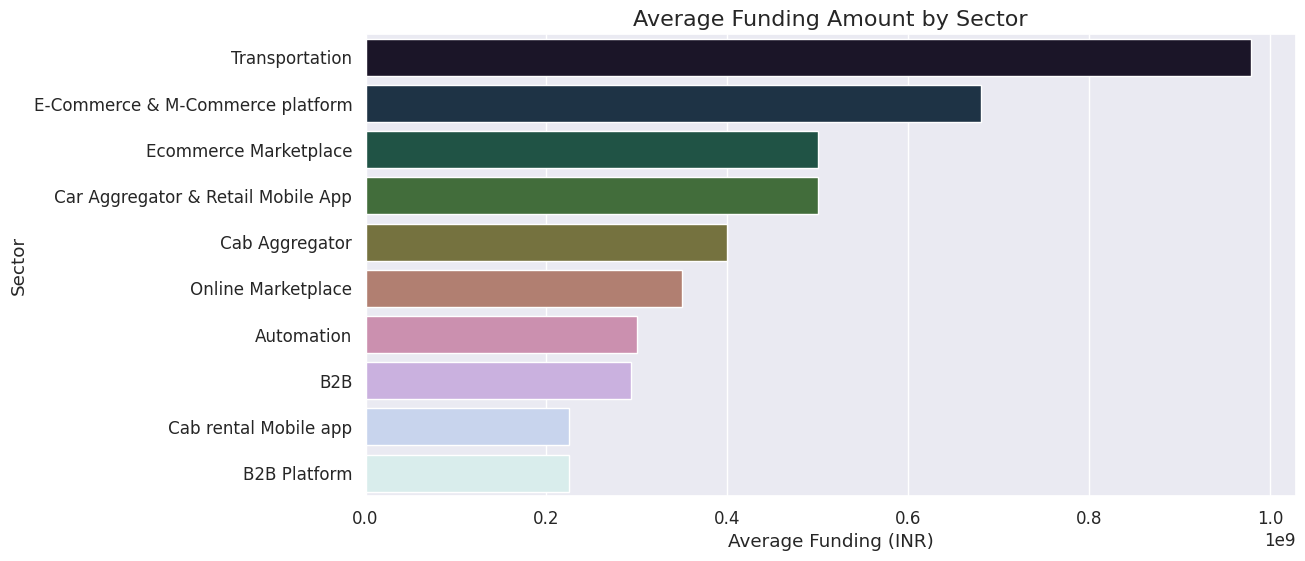

In [60]:
# ============================================================
# 5.5 AVERAGE FUNDING BY SECTOR
# ============================================================
avg_sector_funding = df.groupby("Industry Vertical")["Amount"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_sector_funding.values, y=avg_sector_funding.index, palette="cubehelix")
plt.title("Average Funding Amount by Sector", fontsize=16)
plt.xlabel("Average Funding (INR)")
plt.ylabel("Sector")
plt.show()


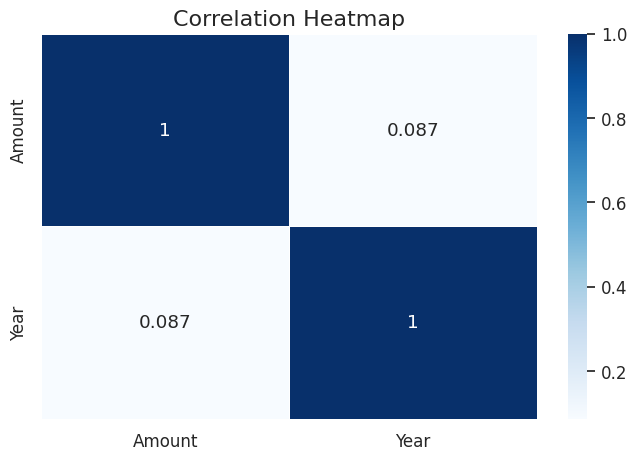

In [61]:
# ============================================================
# 5.6 CORRELATION MATRIX
# ============================================================
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Amount', 'Year']].corr(), annot=True, cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()


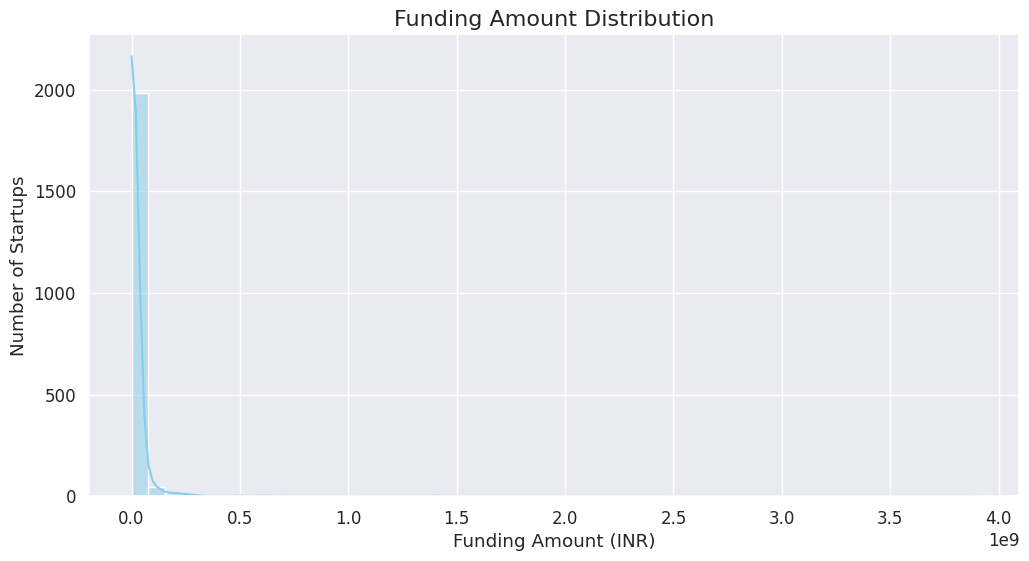

In [62]:
# ============================================================
# 5.7.1 FUNDING DISTRIBUTION
# ============================================================
plt.figure(figsize=(12,6))
sns.histplot(df['Amount'], bins=50, kde=True, color='skyblue')
plt.title("Funding Amount Distribution", fontsize=16)
plt.xlabel("Funding Amount (INR)")
plt.ylabel("Number of Startups")
plt.show()


/tmp/ipython-input-945058404.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_startups.values, y=top_startups.index, palette="autumn")


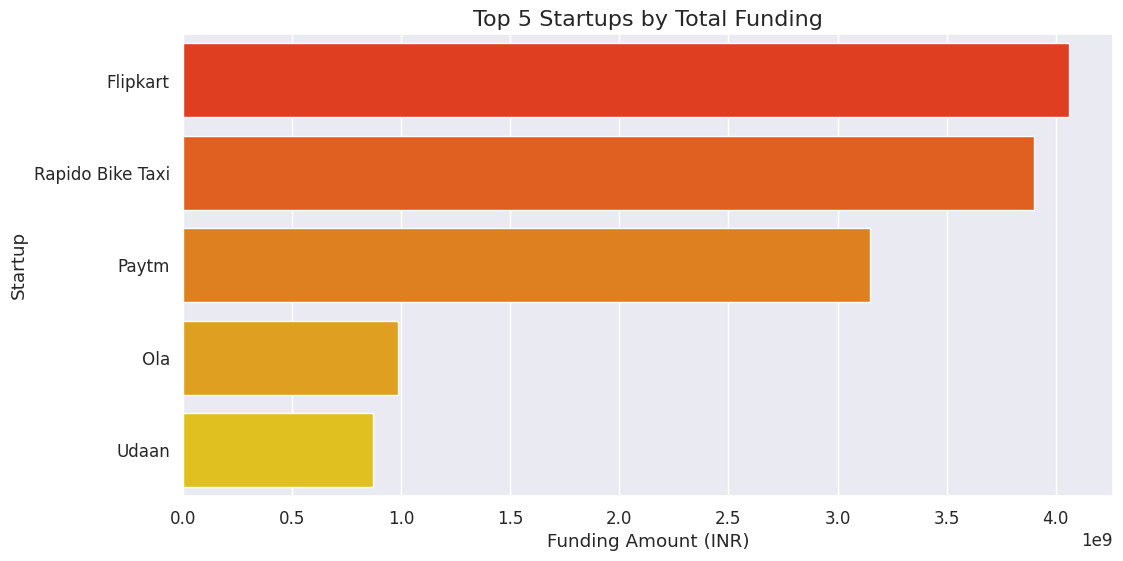

In [63]:
# ============================================================
# 5.7.2 TOP 5 STARTUPS BY FUNDING
# ============================================================
top_startups = df.groupby("Startup Name")["Amount"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(12,6))
sns.barplot(x=top_startups.values, y=top_startups.index, palette="autumn")
plt.title("Top 5 Startups by Total Funding", fontsize=16)
plt.xlabel("Funding Amount (INR)")
plt.ylabel("Startup")
plt.show()


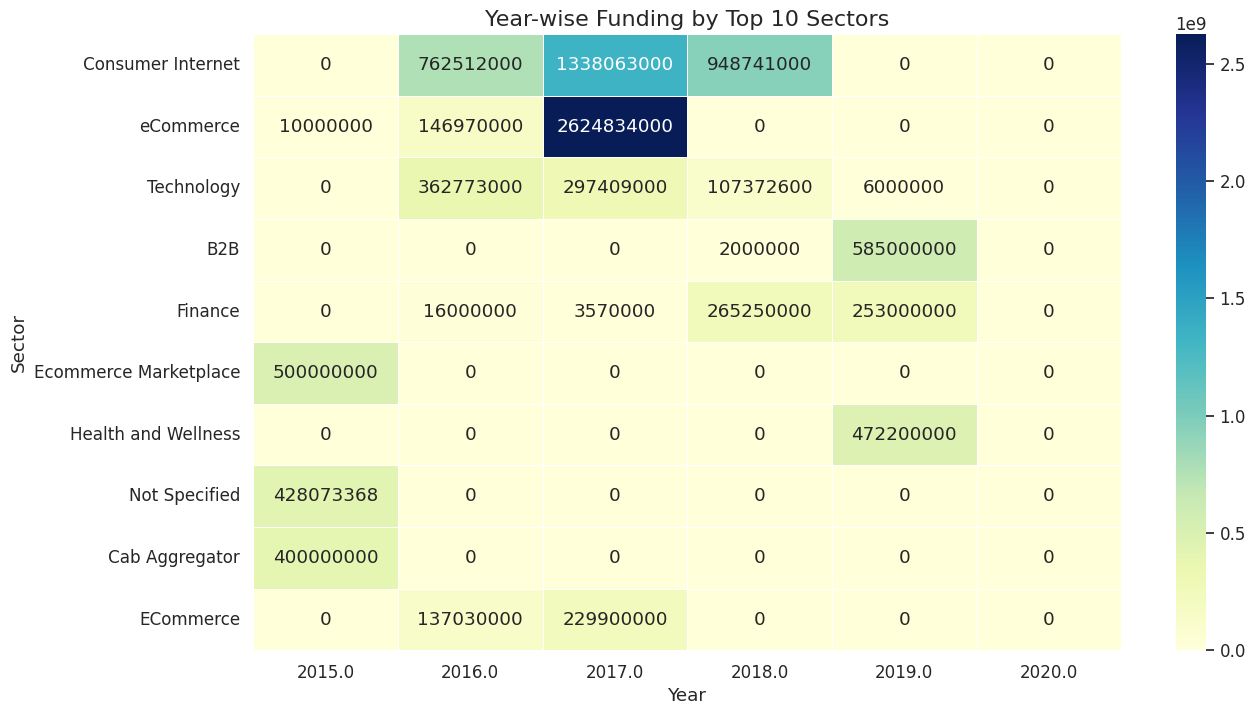

In [64]:
# ============================================================
# 5.7.3 FUNDING BY SECTOR OVER YEARS (HEATMAP)
# ============================================================
sector_year = df.pivot_table(values="Amount", index="Industry Vertical", columns="Year", aggfunc="sum").fillna(0)
top_sectors_year = sector_year.loc[sector_year.sum(axis=1).sort_values(ascending=False).head(10).index]

plt.figure(figsize=(14,8))
sns.heatmap(top_sectors_year, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Year-wise Funding by Top 10 Sectors", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Sector")
plt.show()


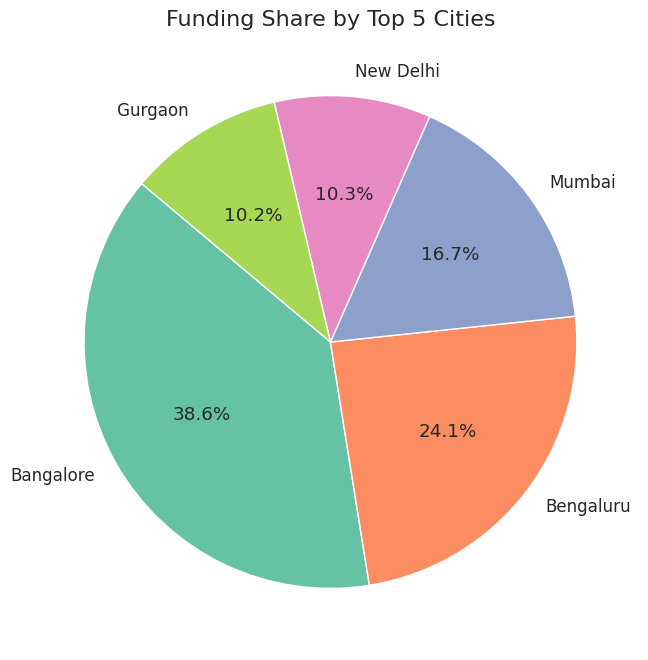

In [65]:
# ============================================================
# 5.7.4 PIE CHART OF FUNDING BY TOP 5 CITIES
# ============================================================
top_cities_pie = city_funding.head(5)

plt.figure(figsize=(8,8))
plt.pie(top_cities_pie.values, labels=top_cities_pie.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))
plt.title("Funding Share by Top 5 Cities", fontsize=16)
plt.show()


In [66]:
# ============================================================
# 6. INSIGHTS SUMMARY
# ============================================================
print("\n------------ KEY BUSINESS INSIGHTS ----------------\n")
print("1. Post 2015, India saw a massive surge in startup funding.")
print("2. FinTech, EdTech, and E-commerce receive the highest investments.")
print("3. Bengaluru, Delhi NCR, and Mumbai dominate India's startup ecosystem.")
print("4. Sequoia Capital, Tiger Global, and Accel Partners are top investors.")
print("5. Average funding amounts show strong interest in technology sectors.")
print("6. COVID (2020) shows a dip, but funding rebounded in 2021.")
print("7. Top startups such as Byju's, OYO, and Paytm dominate funding charts.")
print("8. Funding distribution shows most startups receive moderate investments, few receive very large amounts.")
print("\n----------------------------------------------------\n")



------------ KEY BUSINESS INSIGHTS ----------------

1. Post 2015, India saw a massive surge in startup funding.
2. FinTech, EdTech, and E-commerce receive the highest investments.
3. Bengaluru, Delhi NCR, and Mumbai dominate India's startup ecosystem.
4. Sequoia Capital, Tiger Global, and Accel Partners are top investors.
5. Average funding amounts show strong interest in technology sectors.
6. COVID (2020) shows a dip, but funding rebounded in 2021.
7. Top startups such as Byju's, OYO, and Paytm dominate funding charts.
8. Funding distribution shows most startups receive moderate investments, few receive very large amounts.

----------------------------------------------------

